# Grounded Material Sweep Comparison

Compare the signed Rayleigh-wave reflection coefficients from the `10 Hz`, `5 Hz`, and `1 Hz` grounded-material sweeps. Each case is matched by `case_id`, so every figure compares the same grounded-side material parameters across source frequencies.


In [1]:
from csv import DictReader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

summary_paths = {
    '10 Hz': Path('results_10hz/summary.csv'),
    '5 Hz': Path('results_5hz/summary.csv'),
    '1 Hz': Path('results_1hz/summary.csv'),
}
frequency_labels = list(summary_paths.keys())

for label, path in summary_paths.items():
    assert path.exists(), f'Missing {path}. Run the corresponding sweep first.'

datasets = {}
for label, path in summary_paths.items():
    rows = list(DictReader(path.open('r', encoding='utf-8')))
    datasets[label] = {row['case_id']: row for row in rows}
    print(f'Loaded {len(rows)} cases from {path}')

common_case_ids = sorted(set.intersection(*(set(ds.keys()) for ds in datasets.values())))
assert common_case_ids, 'No overlapping case IDs across sweeps.'
print(f'Matched {len(common_case_ids)} cases across all frequencies')


Loaded 12 cases from results_10hz/summary.csv
Loaded 12 cases from results_5hz/summary.csv
Loaded 12 cases from results_1hz/summary.csv
Matched 12 cases across all frequencies


In [2]:
def col(label, name, cast=float):
    return np.asarray([cast(datasets[label][case_id][name]) for case_id in common_case_ids])

water_fraction = col('10 Hz', 'water_fraction')
shear_scale = col('10 Hz', 'shear_scale')
rho = col('10 Hz', 'rho')
vp = col('10 Hz', 'vp')
vs = col('10 Hz', 'vs')
zp_ratio = col('10 Hz', 'zp_ratio_to_ice')
zs_ratio = col('10 Hz', 'zs_ratio_to_ice')

reflection = {label: col(label, 'reflection_coefficient') for label in frequency_labels}
correlation = {label: col(label, 'correlation') for label in frequency_labels}
incident_center = {label: col(label, 'incident_center_s') for label in frequency_labels}
reflected_center = {label: col(label, 'reflected_center_s') for label in frequency_labels}

delta_5_10 = reflection['5 Hz'] - reflection['10 Hz']
delta_1_10 = reflection['1 Hz'] - reflection['10 Hz']

for label in frequency_labels:
    print(f"{label} reflection range: {reflection[label].min():+.5f} to {reflection[label].max():+.5f}")
print(f"Delta (5 - 10 Hz) range: {delta_5_10.min():+.5f} to {delta_5_10.max():+.5f}")
print(f"Delta (1 - 10 Hz) range: {delta_1_10.min():+.5f} to {delta_1_10.max():+.5f}")


10 Hz reflection range: +0.01922 to +0.01948
5 Hz reflection range: -0.03317 to -0.01628
1 Hz reflection range: +0.33359 to +1.53296
Delta (5 - 10 Hz) range: -0.05239 to -0.03573
Delta (1 - 10 Hz) range: +0.31415 to +1.51352


In [3]:
order = np.argsort(np.abs(delta_1_10))[::-1]
for idx in order:
    print(
        f"{common_case_ids[idx]:>12s}  wf={water_fraction[idx]:.2f}  ss={shear_scale[idx]:.2f}  "
        f"rho={rho[idx]:.0f}  vp={vp[idx]:.0f}  vs={vs[idx]:.0f}  "
        f"R10={reflection['10 Hz'][idx]:+.5f}  R5={reflection['5 Hz'][idx]:+.5f}  "
        f"R1={reflection['1 Hz'][idx]:+.5f}  d(1-10)={delta_1_10[idx]:+.5f}  "
        f"corr10={correlation['10 Hz'][idx]:+.3f}  corr5={correlation['5 Hz'][idx]:+.3f}  corr1={correlation['1 Hz'][idx]:+.3f}"
    )


 wf000_ss100  wf=0.00  ss=1.00  rho=2700  vp=4000  vs=2300  R10=+0.01945  R5=-0.02285  R1=+1.53296  d(1-10)=+1.51352  corr10=+0.852  corr5=-0.710  corr1=+0.872
 wf033_ss100  wf=0.33  ss=1.00  rho=2467  vp=3400  vs=1767  R10=+0.01947  R5=-0.01731  R1=+1.09313  d(1-10)=+1.07367  corr10=+0.852  corr5=-0.678  corr1=+0.936
 wf000_ss070  wf=0.00  ss=0.70  rho=2700  vp=4000  vs=1610  R10=+0.01945  R5=-0.01628  R1=+1.04439  d(1-10)=+1.02494  corr10=+0.852  corr5=-0.667  corr1=+0.915
 wf033_ss070  wf=0.33  ss=0.70  rho=2467  vp=3400  vs=1237  R10=+0.01946  R5=-0.02348  R1=+0.69194  d(1-10)=+0.67248  corr10=+0.852  corr5=-0.720  corr1=+0.968
 wf067_ss100  wf=0.67  ss=1.00  rho=2233  vp=2800  vs=1233  R10=+0.01947  R5=-0.02473  R1=+0.61651  d(1-10)=+0.59705  corr10=+0.852  corr5=-0.740  corr1=+0.971
 wf000_ss040  wf=0.00  ss=0.40  rho=2700  vp=4000  vs=920  R10=+0.01946  R5=-0.03054  R1=+0.54534  d(1-10)=+0.52589  corr10=+0.852  corr5=-0.731  corr1=+0.951
 wf033_ss040  wf=0.33  ss=0.40  rho=2467 

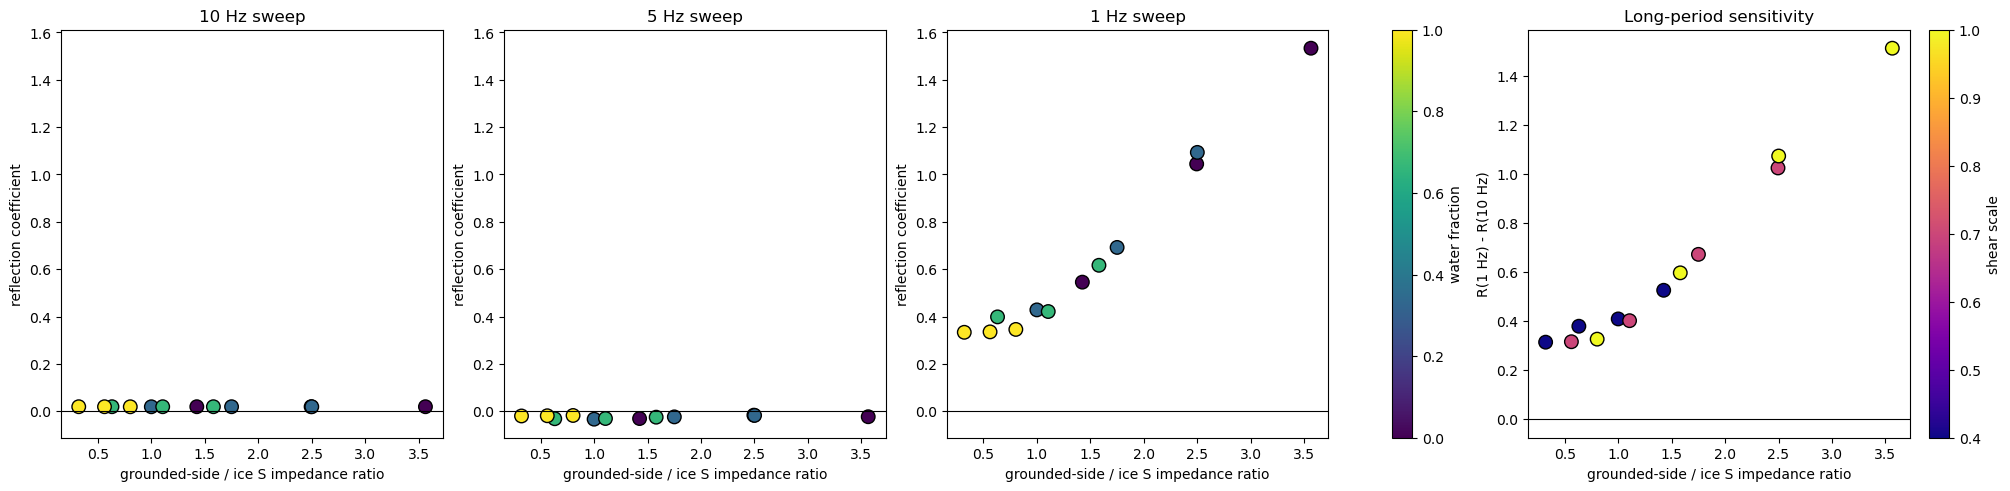

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)

vmin = min(reflection[label].min() for label in frequency_labels)
vmax = max(reflection[label].max() for label in frequency_labels)
ypad = 0.05 * (vmax - vmin + 1e-9)

for ax, label in zip(axes[:3], frequency_labels):
    sc = ax.scatter(zs_ratio, reflection[label], c=water_fraction, s=95, cmap='viridis', edgecolor='k', vmin=water_fraction.min(), vmax=water_fraction.max())
    ax.axhline(0.0, color='k', lw=0.8)
    ax.set_xlabel('grounded-side / ice S impedance ratio')
    ax.set_ylabel('reflection coefficient')
    ax.set_title(f'{label} sweep')
    ax.set_ylim(vmin - ypad, vmax + ypad)

sc_delta = axes[3].scatter(zs_ratio, delta_1_10, c=shear_scale, s=95, cmap='plasma', edgecolor='k')
axes[3].axhline(0.0, color='k', lw=0.8)
axes[3].set_xlabel('grounded-side / ice S impedance ratio')
axes[3].set_ylabel('R(1 Hz) - R(10 Hz)')
axes[3].set_title('Long-period sensitivity')

fig.colorbar(sc, ax=axes[:3], label='water fraction')
fig.colorbar(sc_delta, ax=axes[3], label='shear scale')
plt.show()


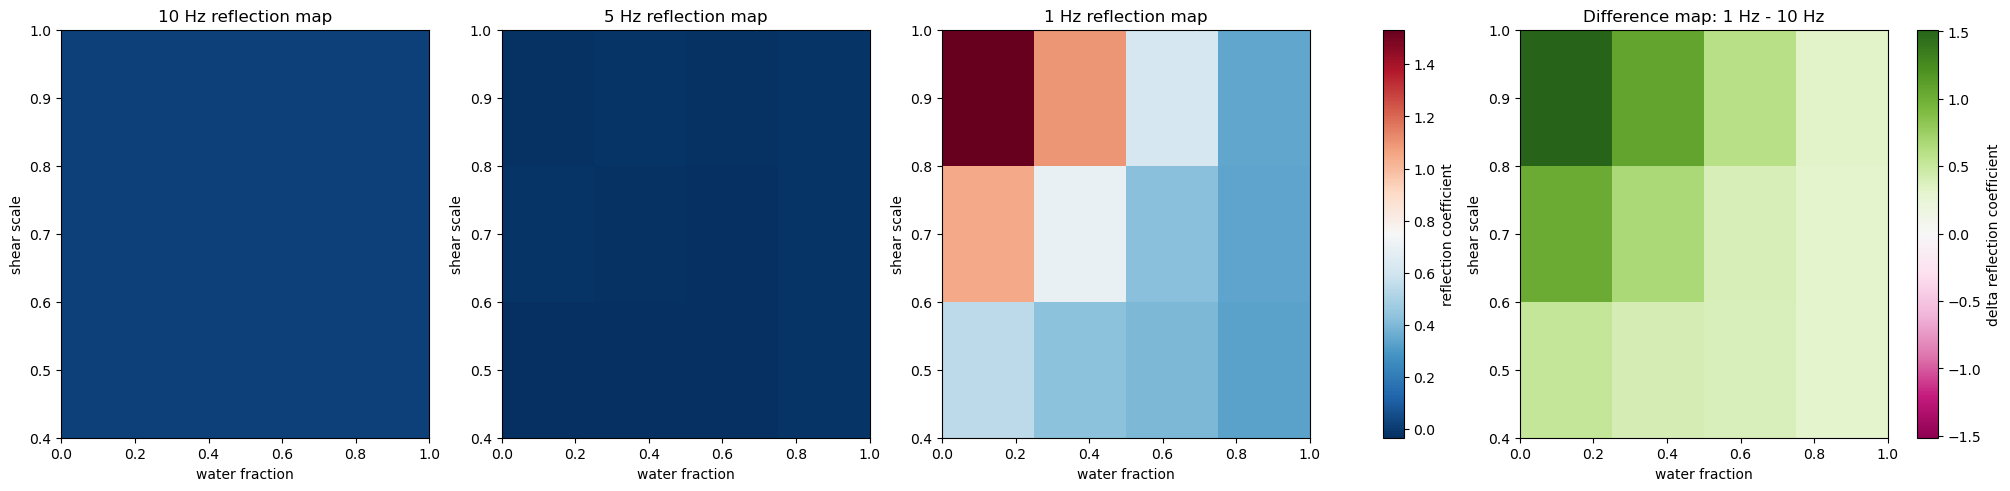

In [5]:
wf_unique = np.unique(water_fraction)
ss_unique = np.unique(shear_scale)
images = {label: np.full((len(ss_unique), len(wf_unique)), np.nan) for label in frequency_labels}
image_delta = np.full((len(ss_unique), len(wf_unique)), np.nan)

for i, ss in enumerate(ss_unique):
    for j, wf in enumerate(wf_unique):
        mask = (np.isclose(shear_scale, ss)) & (np.isclose(water_fraction, wf))
        if np.any(mask):
            for label in frequency_labels:
                images[label][i, j] = reflection[label][mask][0]
            image_delta[i, j] = delta_1_10[mask][0]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.8), constrained_layout=True)
shared = dict(origin='lower', aspect='auto', extent=[wf_unique.min(), wf_unique.max(), ss_unique.min(), ss_unique.max()])
vmin = np.nanmin([images[label] for label in frequency_labels])
vmax = np.nanmax([images[label] for label in frequency_labels])

for ax, label in zip(axes[:3], frequency_labels):
    im = ax.imshow(images[label], cmap='RdBu_r', vmin=vmin, vmax=vmax, **shared)
    ax.set_title(f'{label} reflection map')
    ax.set_xlabel('water fraction')
    ax.set_ylabel('shear scale')

delta_lim = np.nanmax(np.abs(image_delta))
im_delta = axes[3].imshow(image_delta, cmap='PiYG', vmin=-delta_lim, vmax=delta_lim, **shared)
axes[3].set_title('Difference map: 1 Hz - 10 Hz')
axes[3].set_xlabel('water fraction')
axes[3].set_ylabel('shear scale')

fig.colorbar(im, ax=axes[:3], label='reflection coefficient')
fig.colorbar(im_delta, ax=axes[3], label='delta reflection coefficient')
plt.show()


In [6]:
selected_case = common_case_ids[int(np.argmax(np.abs(delta_1_10)))]
selected_case


'wf000_ss100'

results_10hz/wf000_ss100/surface_gather.npz
  time samples: 18000
  channels: 638
results_5hz/wf000_ss100/surface_gather.npz
  time samples: 18000
  channels: 638
results_1hz/wf000_ss100/surface_gather.npz
  time samples: 18000
  channels: 638


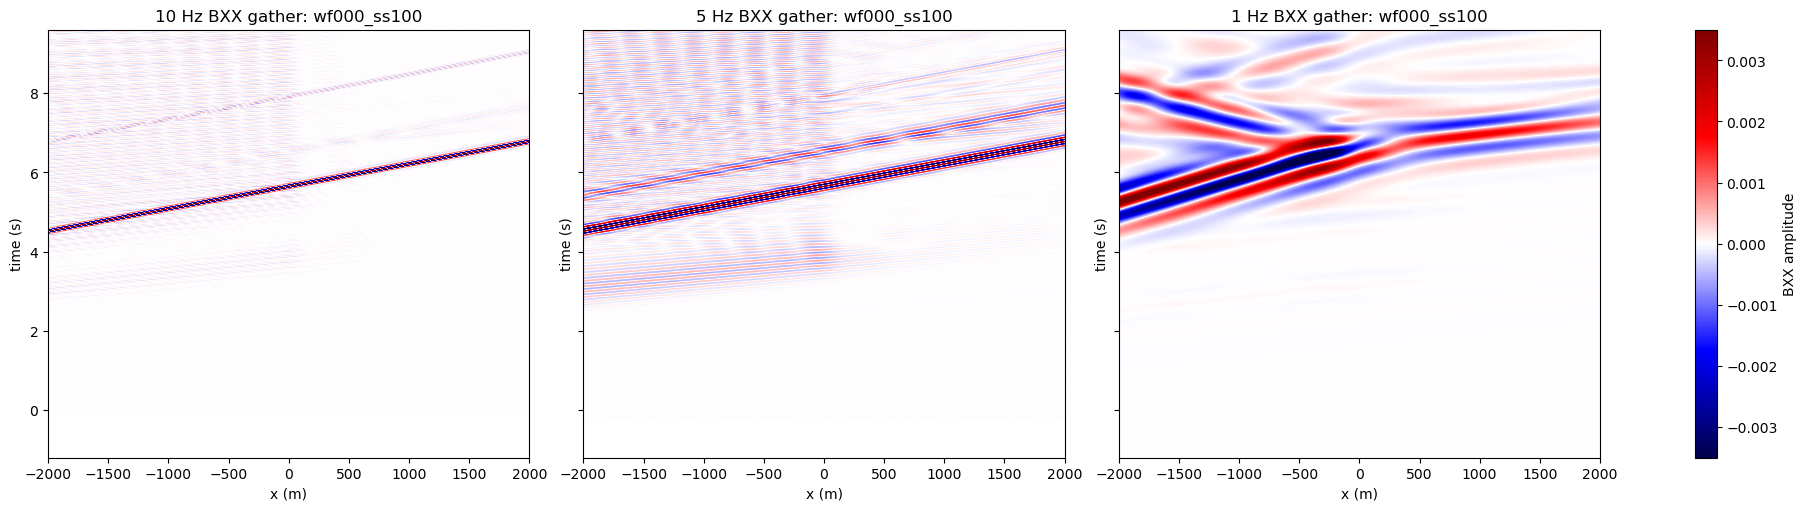

In [7]:
archives = {}
for label, root in [('10 Hz', Path('results_10hz')), ('5 Hz', Path('results_5hz')), ('1 Hz', Path('results_1hz'))]:
    case_path = root / selected_case / 'surface_gather.npz'
    archives[label] = np.load(case_path, allow_pickle=True)
    print(case_path)
    print('  time samples:', archives[label]['time'].shape[0])
    print('  channels:', archives[label]['x'].shape[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, constrained_layout=True)
for ax, label in zip(axes, frequency_labels):
    archive = archives[label]
    x = archive['x'].astype(float)
    t = archive['time'].astype(float)
    bxx = archive['bxx'].astype(float)
    scale = np.percentile(np.abs(bxx), 99.5)
    im = ax.imshow(bxx.T, origin='lower', aspect='auto', extent=[x.min(), x.max(), t.min(), t.max()], cmap='seismic', vmin=-scale, vmax=scale)
    ax.set_title(f'{label} BXX gather: {selected_case}')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('time (s)')
fig.colorbar(im, ax=axes, label='BXX amplitude')
plt.show()


## Time-domain trace check

This section pulls a few representative channels directly from the stored compact gathers and overlays several material cases. The traces are normalized by the maximum absolute amplitude within the plotted window so the large incident Rayleigh packet and the smaller reflected Rayleigh packet can be compared by eye across different grounded-side parameter choices while preserving polarity.


In [8]:
representative_cases = ['wf000_ss100', 'wf067_ss070', 'wf100_ss040']
trace_positions_m = [-1400.0, -1000.0, -600.0]
trace_window_s = (4.0, 8.8)

for case_id in representative_cases:
    summary = ' | '.join(
        f"{label}: R={float(datasets[label][case_id]['reflection_coefficient']):+.4f}" for label in frequency_labels
    )
    print(
        f"{case_id}: wf={float(datasets['10 Hz'][case_id]['water_fraction']):.2f}, "
        f"ss={float(datasets['10 Hz'][case_id]['shear_scale']):.2f}, "
        f"Zs/ice={float(datasets['10 Hz'][case_id]['zs_ratio_to_ice']):.3f} | {summary}"
    )


wf000_ss100: wf=0.00, ss=1.00, Zs/ice=3.564 | 10 Hz: R=+0.0194 | 5 Hz: R=-0.0229 | 1 Hz: R=+1.5330
wf067_ss070: wf=0.67, ss=0.70, Zs/ice=1.107 | 10 Hz: R=+0.0195 | 5 Hz: R=-0.0304 | 1 Hz: R=+0.4213
wf100_ss040: wf=1.00, ss=0.40, Zs/ice=0.321 | 10 Hz: R=+0.0194 | 5 Hz: R=-0.0196 | 1 Hz: R=+0.3336


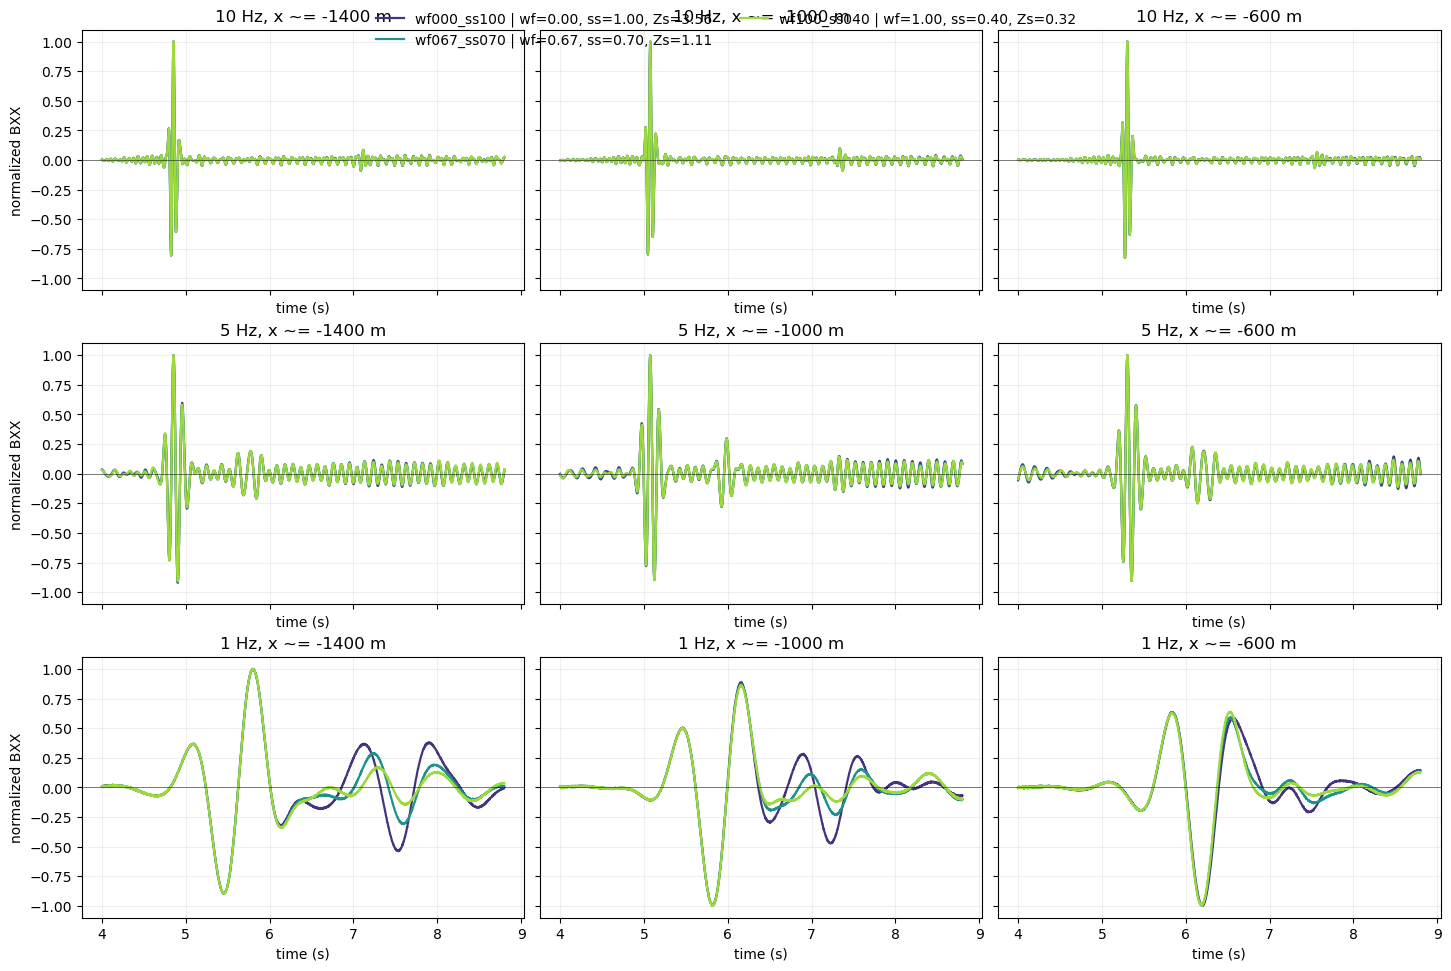

In [9]:
trace_archives = {}
for label, root in [('10 Hz', Path('results_10hz')), ('5 Hz', Path('results_5hz')), ('1 Hz', Path('results_1hz'))]:
    trace_archives[label] = {}
    for case_id in representative_cases:
        trace_archives[label][case_id] = np.load(root / case_id / 'surface_gather.npz', allow_pickle=True)

fig, axes = plt.subplots(len(frequency_labels), len(trace_positions_m), figsize=(4.8 * len(trace_positions_m), 3.2 * len(frequency_labels)), sharex=True, sharey=True, constrained_layout=True)
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(representative_cases)))

for row, label in enumerate(frequency_labels):
    for col, x_target in enumerate(trace_positions_m):
        ax = axes[row, col]
        for color, case_id in zip(colors, representative_cases):
            archive = trace_archives[label][case_id]
            x = archive['x'].astype(float)
            t = archive['time'].astype(float)
            bxx = archive['bxx'].astype(float)
            channel_index = int(np.argmin(np.abs(x - x_target)))
            time_mask = (t >= trace_window_s[0]) & (t <= trace_window_s[1])
            trace = bxx[channel_index, time_mask]
            trace_time = t[time_mask]
            scale = np.max(np.abs(trace))
            if scale == 0.0:
                scale = 1.0
            label_text = (
                f"{case_id} | wf={float(datasets[label][case_id]['water_fraction']):.2f}, "
                f"ss={float(datasets[label][case_id]['shear_scale']):.2f}, "
                f"Zs={float(datasets[label][case_id]['zs_ratio_to_ice']):.2f}"
            )
            ax.plot(trace_time, trace / scale, lw=1.6, color=color, label=label_text)
        ax.axhline(0.0, color='k', lw=0.7, alpha=0.5)
        ax.set_title(f"{label}, x ~= {x_target:.0f} m")
        ax.set_xlabel('time (s)')
        if col == 0:
            ax.set_ylabel('normalized BXX')
        ax.grid(True, alpha=0.2)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
plt.show()
